In [1]:
%load_ext autoreload
%autoreload 2

In [18]:
import sys
sys.path.append('..')
from firstpassage.FPTCalculator import *
from lo_circuit.fusion_network import *
from lo_circuit.fusion_order import *
from graphtheory.ghz_partitioning import *
import random
import perceval as pcvl
import itertools
import networkx as nx


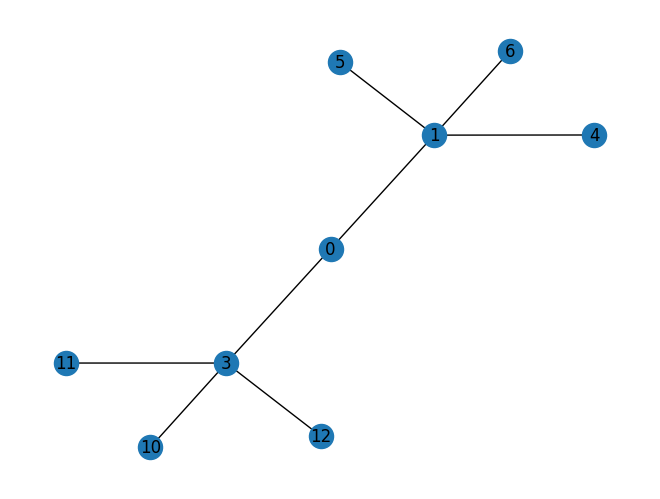

In [110]:
# random.seed(1234)
# random.seed(204)
random.seed(19)
def connect_graph(G):
    C = list(nx.connected_components(G))
    for idx in range(1,len(C)):
        G.add_edge(list(C[idx-1])[0],list(C[idx])[0])

G = nx.erdos_renyi_graph(7, 0.3)
connect_graph(G)
G = nx.balanced_tree(3,2)
G.remove_nodes_from([2,7,9,8])
nx.draw(G,with_labels=True)

In [116]:
G.edges

EdgeView([(0, 1), (0, 3), (1, 4), (1, 5), (1, 6), (3, 10), (3, 11), (3, 12)])

In [111]:
T = get_spanning_tree(G,'dfs','random',True)
fusion_network = build_fusion_network_from_spanning_tree(T,0,G)
fusion_network

[(0, 3), (4, 6), (7, 9), (2, 12), (13, 15), (16, 18)]

In [112]:
def compare_fusion_order(fusion_network):
    random_order = fusion_network[:]
    random.shuffle(random_order)
    min_order = approximate_minimal_fpt_fusion_order(fusion_network)
    for name, order in [('tree',fusion_network),('random',random_order),('approx_min',min_order)]:
        print(name,order)
        max_qubit = int(max([q for f in order for q in f])/3)*3+3
        fpt = get_fp_times(order, max_qubit, [0.5,0.66,0.75,0.85,1])
        print(name,":",fpt)
compare_fusion_order(fusion_network)

tree [(0, 3), (4, 6), (7, 9), (2, 12), (13, 15), (16, 18)]
tree : {0.5: 74.6666666735024, 0.66: 21.552529268804648, 0.75: 13.649045060304124, 0.85: 9.273822898025292, 1: 6.000000002012098}
random [(7, 9), (2, 12), (4, 6), (13, 15), (0, 3), (16, 18)]
random : {0.5: 48.61538464729858, 0.66: 18.167646998591437, 0.75: 12.328203931578052, 0.85: 8.790612508969646, 1: 6.0000000030021745}
approx_min [(7, 9), (2, 12), (16, 18), (13, 15), (4, 6), (0, 3)]
approx_min : {0.5: 27.333333323215243, 0.66: 13.974022615658896, 0.75: 10.564102550824797, 0.85: 8.176459514835114, 1: 5.999999991296186}


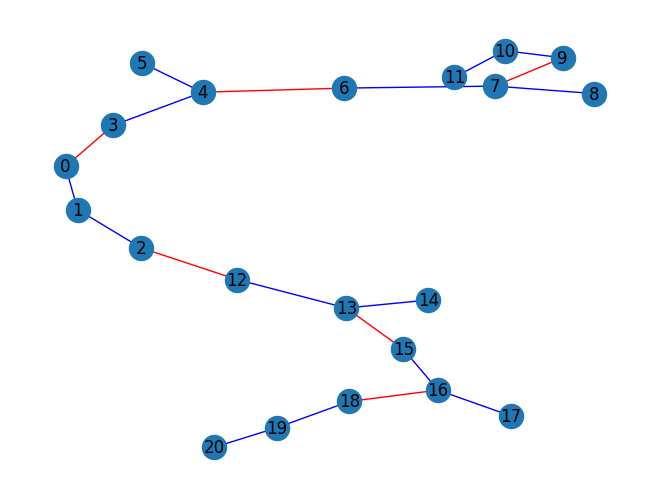

In [114]:
draw_fusion_network([(7, 9), (2, 12), (16, 18), (13, 15), (4, 6), (0, 3)])

In [ ]:
(4, 6), (16, 18), (7, 9), (2, 12), (13, 15), (0, 3)

[(10, 15), (11, 12), (4, 6), (8, 9), (14, 1), (0, 3)] #best

In [113]:
#Wie nahe sind wir mit approx_min dran an der optimalen Lösung? 
# approx_opt = {0.5: 45.00000001670095, 0.66: 17.488746736183646, 0.75: 11.94207027628623, 0.85: 8.595448952949198, 1: 6.000000005859789}
approx_opt = {0.5: 27.333333323215243, 0.66: 13.974022615658896, 0.75: 10.564102550824797, 0.85: 8.176459514835114, 1: 5.999999991296186}
better_count = 0
for order in itertools.permutations(fusion_network):
    max_qubit = int(max([q for f in order for q in f])/3)*3+3
    fpt = get_fp_times(list(order), max_qubit, [0.5,0.66,0.75,0.85,1])
    better = []
    for k,v in fpt.items():
        if abs(fpt[k]-approx_opt[k]) < 1.0e-03:
            continue
        if approx_opt[k] > v:
            better.append(k)
    if better:
        better_count += 1
        print("fusion order ",order,"better for percentages",better,"differences ",[fpt[k]-approx_opt[k] for k in better])
print(better_count)

fusion order  ((4, 6), (7, 9), (16, 18), (2, 12), (13, 15), (0, 3)) better for percentages [0.5, 0.66, 0.75, 0.85] differences  [-1.3333333004250285, -0.17626540495672138, -0.045584029456398056, -0.006298687741150388]
fusion order  ((4, 6), (16, 18), (7, 9), (2, 12), (13, 15), (0, 3)) better for percentages [0.5, 0.66, 0.75, 0.85] differences  [-1.3333333313622653, -0.17626541002484153, -0.04558402443721832, -0.006298700434523852]
fusion order  ((4, 6), (16, 18), (2, 12), (7, 9), (13, 15), (0, 3)) better for percentages [0.5, 0.66, 0.75] differences  [-0.3333332855694202, -0.039553977260124995, -0.008547006208393881]
fusion order  ((4, 6), (16, 18), (2, 12), (13, 15), (7, 9), (0, 3)) better for percentages [0.5, 0.66, 0.75] differences  [-0.33333333133499465, -0.03955395544051754, -0.008546992028602318]
fusion order  ((7, 9), (4, 6), (16, 18), (2, 12), (13, 15), (0, 3)) better for percentages [0.5, 0.66, 0.75, 0.85] differences  [-1.3333333004250285, -0.17626540495672138, -0.0455840294

In [39]:
better_order = [(4, 6), (10, 15), (8, 9), (14, 1), (0, 3), (11, 12)]
max_qubit = int(max([q for f in better_order for q in f])/3)*3+3
get_fp_times(better_order, max_qubit, [0.5,0.66,0.75,0.85,1])

{0.5: 40.499999990619564,
 0.66: 16.691166734553363,
 0.75: 11.682098772261082,
 0.85: 8.541925405277834,
 1: 5.999999993657355}

In [115]:
len([(62, 63), (32, 33), (10, 12), (49, 57), (52, 66), (17, 24), (28, 56), (20, 21), (38, 39), (0, 3), (7, 45), (43, 71), (5, 18), (2, 23), (44, 60), (53, 54), (47, 48), (14, 30), (16, 41), (6, 29), (25, 42), (4, 11), (19, 35), (1, 15), (34, 36), (13, 65), (8, 9), (26, 27), (40, 50), (31, 51), (68, 69)])

31